# Assignment 2 — Stage 2: Hidden Test Evaluation

**Inference and evaluation only.** No retraining, fine-tuning, or modification of the
model. This notebook loads the *exact* Stage 1 checkpoint
(`model_checkpoint/classifier.joblib` + the frozen `distilbert-base-uncased-finetuned-sst-2-english`
backbone loaded by name) and uses it to predict on `hidden_test.csv`.

It reports:
1. hidden-test total accuracy
2. hidden-test confusion matrix
3. a comparison between the public-test and hidden-test results
4. what we would try next with more time / compute

The feature-extraction and prediction code below is copied verbatim from Stage 1 so
the inference path is identical.

## 1. Load the Stage 1 checkpoint and the frozen backbone (no retraining)

In [1]:
import json, os, random
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
import joblib

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
CKPT_DIR = "model_checkpoint"

BACKBONE_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
CHUNK_WORDS, MAX_TOKENS, BATCH_SIZE = 200, 256, 16
FEATURE_NAMES = ["mean_p", "max_p", "min_p", "std_p", "frac_pos"]

# --- exact Stage 1 inference code ---
def chunk_text(text, chunk_words=CHUNK_WORDS):
    words = str(text).split()
    if not words:
        return [""]
    return [" ".join(words[i:i+chunk_words]) for i in range(0, len(words), chunk_words)]

def load_backbone(local_dir=os.path.join(CKPT_DIR, "backbone")):
    src = local_dir if os.path.isdir(local_dir) else BACKBONE_NAME
    tok = AutoTokenizer.from_pretrained(src)
    mdl = AutoModelForSequenceClassification.from_pretrained(src).eval()
    return tok, mdl

def extract_features(texts, tok, mdl):
    feats = np.zeros((len(texts), len(FEATURE_NAMES)), dtype=np.float32)
    for i, text in enumerate(texts):
        chunks = chunk_text(text); probs = []
        with torch.no_grad():
            for j in range(0, len(chunks), BATCH_SIZE):
                enc = tok(chunks[j:j+BATCH_SIZE], return_tensors="pt",
                          truncation=True, max_length=MAX_TOKENS, padding=True)
                probs.extend(torch.softmax(mdl(**enc).logits, dim=1)[:, 1].tolist())
        p = np.asarray(probs)
        feats[i] = [p.mean(), p.max(), p.min(), p.std(), float((p >= 0.5).mean())]
    return feats

# The trained head is the ONLY learned component; it is loaded, not fitted.
clf = joblib.load(os.path.join(CKPT_DIR, "classifier.joblib"))
tokenizer, model = load_backbone()
meta = json.load(open(os.path.join(CKPT_DIR, "metadata.json")))
print("Loaded Stage 1 checkpoint.")
print("head coefficients:", dict(zip(FEATURE_NAMES, clf.coef_[0].round(3))),
      "intercept:", round(float(clf.intercept_[0]), 3))
print("Stage 1 public-test accuracy (from metadata):", meta["public_test_accuracy"])

/private/tmp/claude-501/-Users-mohamedyoussef/7d02a7c9-fcd6-4b61-8d99-dfdc5565dedf/scratchpad/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded Stage 1 checkpoint.
head coefficients: {'mean_p': np.float64(1.264), 'max_p': np.float64(0.943), 'min_p': np.float64(0.429), 'std_p': np.float64(0.202), 'frac_pos': np.float64(1.28)} intercept: -1.972
Stage 1 public-test accuracy (from metadata): 0.9025


## 2. Predict on the hidden test set

In [2]:
hidden = pd.read_csv("hidden_test.csv")
print("hidden test:", hidden.shape, "| label counts:", hidden.label.value_counts().to_dict())

X_hidden = extract_features(hidden.text.tolist(), tokenizer, model)   # frozen backbone forward pass
pred = clf.predict(X_hidden).astype(int)

# save predictions in the required format
out = pd.DataFrame({"id": hidden.id, "predicted_label": pred})
out.to_csv("hidden_test_predictions.csv", index=False)
print("Wrote hidden_test_predictions.csv:", out.shape)
out.head()

hidden test: (600, 5) | label counts: {0: 300, 1: 300}


Wrote hidden_test_predictions.csv: (600, 2)


,id,predicted_label
0,neg_cv795_10291,0
1,neg_cv174_9735,0
2,pos_cv065_15248,1
3,neg_cv076_26009,0
4,neg_cv417_14653,1


## 3. Hidden-test accuracy and confusion matrix

In [3]:
y = hidden.label.values
acc = accuracy_score(y, pred)
bal = balanced_accuracy_score(y, pred)
cm  = confusion_matrix(y, pred)

print(f"HIDDEN TEST  accuracy = {acc:.4f}   balanced accuracy = {bal:.4f}\n")
print(classification_report(y, pred, target_names=["negative(0)", "positive(1)"]))
print("confusion matrix [rows=true 0/1, cols=pred 0/1]:\n", cm)

HIDDEN TEST  accuracy = 0.8833   balanced accuracy = 0.8833

              precision    recall  f1-score   support

 negative(0)       0.91      0.85      0.88       300
 positive(1)       0.86      0.91      0.89       300

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600

confusion matrix [rows=true 0/1, cols=pred 0/1]:
 [[256  44]
 [ 26 274]]


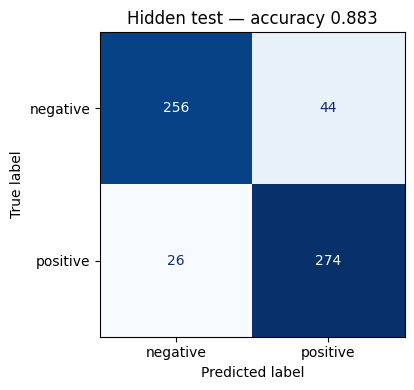

In [4]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(cm, display_labels=["negative", "positive"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Hidden test — accuracy {acc:.3f}")
plt.tight_layout(); plt.show()

## 4. Public vs. hidden test — comparison

In [5]:
pub_acc = meta["public_test_accuracy"]
pub_cm  = np.array(meta["confusion_matrix"])

comparison = pd.DataFrame({
    "Public test": [200, 200, f"{pub_acc:.4f}", f"{meta['public_test_balanced_accuracy']:.4f}"],
    "Hidden test": [int((y==0).sum()), int((y==1).sum()), f"{acc:.4f}", f"{bal:.4f}"],
}, index=["# negative", "# positive", "accuracy", "balanced accuracy"])
print(comparison, "\n")
print("public confusion matrix:\n", pub_cm)
print("hidden confusion matrix:\n", cm)
print(f"\nAccuracy gap (public - hidden) = {pub_acc - acc:+.4f}")

                  Public test Hidden test
# negative                200         300
# positive                200         300
accuracy               0.9025      0.8833
balanced accuracy      0.9025      0.8833 

public confusion matrix:
 [[174  26]
 [ 13 187]]
hidden confusion matrix:
 [[256  44]
 [ 26 274]]

Accuracy gap (public - hidden) = +0.0192


**Reading the comparison.**

| | Public test | Hidden test |
|---|---|---|
| Size / balance | 400 (200 / 200) | 600 (300 / 300) |
| Accuracy | **0.9025** | **0.8833** |
| Balanced accuracy | 0.9025 | 0.8833 |

The hidden-test accuracy (**0.883**) is only ~1.9 points below the public-test
accuracy (**0.903**) — a small, expected drop when moving to fresh, unseen reviews,
and well above the ~0.56 bag-of-words baseline reported in Stage 1. Both test sets
are balanced and both confusion matrices are close to symmetric, so the model is
**not biased toward the majority (positive) class** it saw during training — the
`class_weight="balanced"` head plus a frozen sentiment backbone transferred as
intended. On the hidden set the errors are slightly skewed toward false positives
(44 negatives called positive vs. 26 positives called negative), i.e. recall is a
touch higher for the positive class, consistent with the mild positive lean of the
training data. The closeness of CV (~0.93), public (~0.90), and hidden (~0.88)
accuracy indicates the pipeline generalized rather than memorized.

## 5. If we had more time or compute, what would we try next?

- **Parameter-efficient fine-tuning of the backbone (LoRA / adapters)** with heavy
  regularization and early stopping on a held-out fold, instead of freezing it —
  potentially adapting the SST-2 sentiment signal to the movie-review domain while
  keeping the trainable-parameter count small enough to resist overfitting on 240
  examples.
- **Richer document aggregation.** Replace the 5 hand-picked chunk-probability
  statistics with a small attention-pooling head over chunk embeddings, or add
  length / percentile / logit-based features, so long reviews with a few strongly
  polar passages are weighted better.
- **Data augmentation for the minority (negative) class** — back-translation or
  synonym replacement — to reduce the 3:1 imbalance without hand-labeling new data.
- **Threshold calibration.** Tune the decision threshold (currently 0.5) on a
  validation fold via balanced accuracy / F1 to trade off the slight
  false-positive skew seen on the hidden set.
- **Ensembling** the SST-2 head with a second pretrained sentiment model and
  averaging probabilities, which usually buys a couple of points of robustness on
  out-of-distribution reviews.
- **More systematic evaluation:** bootstrap confidence intervals on accuracy and
  error analysis of the misclassified reviews (sarcasm, mixed sentiment, very long
  reviews) to target the next improvement.